# Variants of stochastic gradient-based optimization

In this Notebook I will be demonstrating some different methods to optimize hyperparameters using gradient descent.

First of all, we need to import all the neccessary libraries.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import inv
import time

np.random.seed(42)

After that is done, we generate our data. In our case we want to optimize our model to find the function
$$f(x_1, x_2) = 20x_1 - 3x_2.$$
Here we create this function and add some noise to it.

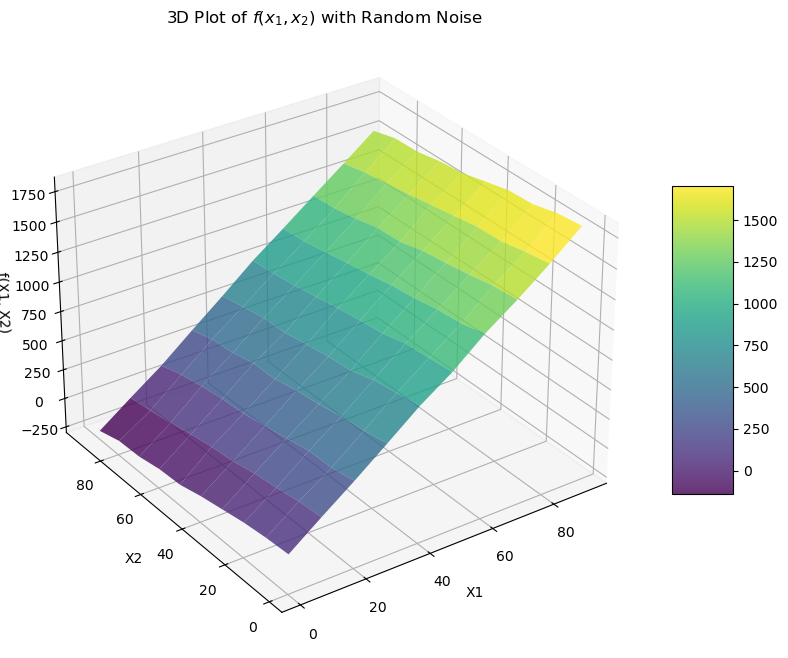

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': '3D Plot of $f(x_1, x_2)$ with Random Noise'}, xlabel='X1', ylabel='X2', zlabel='f(X1, X2)'>)

In [2]:
# Function y = 20*x1 - 3*x2
N = 100
a10 = 20
a20 = -3

# Create grid of points
X1 = np.arange(1, N+1)
X2 = np.arange(1, N+1)
XX = np.array(np.meshgrid(X1, X2)).T.reshape(-1, 2)

# Add random noise
R = np.random.normal(0, 10, N*N)
Y = a10 * XX[:, 0] + a20 * XX[:, 1] + R

# Plot the function
step = max(1, N // 10)
A, B = np.meshgrid(np.arange(1, N+1, step), np.arange(1, N+1, step))

def f0(x1, x2):
    return a10 * x1 + a20 * x2

def f(x1, x2, r):
    return a10 * x1 + a20 * x2 + r

# Function that includes random noise
def ff(x1, x2):
    return f(x1, x2, np.random.normal(0, 10))

# Plot the function
def plot3d(func, X, Y, show_plot=True):
    """
    Create a 3D surface plot
    func: function to evaluate at each point
    X, Y: meshgrid arrays
    show_plot: whether to display the plot
    """
    Z = np.array([[func(x, y) for x, y in zip(row_X, row_Y)] 
                  for row_X, row_Y in zip(X, Y)])
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('f(X1, X2)')
    ax.set_title(f'3D Plot of $f(x_1, x_2)$ with Random Noise')
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    ax.view_init(elev=30, azim=235)
    
    if show_plot:
        plt.show()
    
    return fig, ax

# Create the plot
plot3d(ff, A, B, show_plot=True)

### Here I define some helper functions to use later on

In [3]:
def mse(ws, m, X, Y):
    """Mean squared error loss function"""
    N = len(X)
    predictions = np.array([m(ws, X[i]) for i in range(N)])
    return np.mean((Y - predictions) ** 2)

def grad_mse(ws, m, gradients, X, Y):
    """Gradient of mean squared error"""
    N = len(X)
    grad = np.zeros(len(ws))
    for i in range(N):
        xi = X[i]
        yi = Y[i]
        diff = yi - m(ws, xi)
        for j in range(len(ws)):
            grad[j] += diff * gradients[j](ws, xi)
    return -2/N * grad

def grad_desc_mse(K, ws, learning_eps, loss, grad_loss, verbose=False):
    """Gradient descent optimization"""
    history = [loss(ws)]
    for k in range(K):
        grad_ws = grad_loss(ws)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

### Defining our simple linear model and weight initialization

Here I define the simple one neuron model with no activation with the standard glorot weight initialization.

In [4]:
# Model: linear neural network
m1 = lambda ws, x: ws[0] * x[0] + ws[1] * x[1]
mse1 = lambda ws: mse(ws, m1, XX, Y)

# Glorot uniform initializer
in_units = 2
out_units = 1
limit = np.sqrt(6 / (in_units + out_units))
ws0 = np.array([np.random.rand() * 2 * limit - limit, 
                np.random.rand() * 2 * limit - limit])

print("Initial weights:", ws0)
print("Initial MSE:", mse1(ws0))

# Gradients for the model
gradients1 = [
    lambda ws, x: x[0],
    lambda ws, x: x[1]
]

# Loss gradients
grad_loss = lambda ws: grad_mse(ws, m1, gradients1, XX, Y)
grad_loss2 = lambda ws, randices: grad_mse(ws, m1, gradients1, XX[randices], Y[randices])

Initial weights: [0.12077737 0.84572904]
Initial MSE: 997160.8985653088


I will also add the plotting tool here to help visualize the learning later from now on.

In [5]:
def setup_plot():
    """Setup the 3D plot for optimization visualization"""
    A, B = np.meshgrid(np.arange(min(a10, ws0[0])-10, max(a10, ws0[0])+11, 1),
                       np.arange(min(a20, ws0[1])-10, max(a20, ws0[1])+11, 1))
    
    Z = np.array([[mse1([A[i,j], B[i,j]]) for j in range(A.shape[1])] for i in range(A.shape[0])])
    
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(A, B, Z, cmap='viridis', alpha=0.7)
    ax1.scatter([a10], [a20], [mse1([a10, a20])], color='red', marker='*', s=100)
    ax1.scatter([ws0[0]], [ws0[1]], [mse1(ws0)], color='red', marker='+', s=100)
    ax1.set_xlabel('w1')
    ax1.set_ylabel('w2')
    ax1.set_zlabel('MSE')
    
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(A, B, Z, levels=30, cmap='viridis')
    ax2.plot(a10, a20, '*r', markersize=10)
    ax2.plot(ws0[0], ws0[1], '+r', markersize=10)
    ax2.set_xlabel('w1')
    ax2.set_ylabel('w2')
    plt.colorbar(contour, ax=ax2)
    
    return ax2

### Vanilla gradient descent

To show that all is fine we perform a regular gradient descent.

Testing LR=0.0001, K=10...
  Final MSE: 6218.119702, Time: 0.4527s
Testing LR=0.0001, K=20...
  Final MSE: 260.308008, Time: 0.8467s
Testing LR=0.0001, K=30...
  Final MSE: 104.841956, Time: 1.3612s
Testing LR=0.00015, K=10...
  Final MSE: 6160.741646, Time: 0.4436s
Testing LR=0.00015, K=20...
  Final MSE: 140.094986, Time: 0.8734s
Testing LR=0.00015, K=30...
  Final MSE: 100.942267, Time: 1.0389s
Testing LR=0.0002, K=10...
  Final MSE: 435396575.498792, Time: 0.3493s
Testing LR=0.0002, K=20...
  Final MSE: 248575380790.009399, Time: 0.5987s
Testing LR=0.0002, K=30...
  Final MSE: 141916008679998.843750, Time: 0.9240s

Best: LR=0.00015, K=30, MSE=100.942267
Time: 0.977978 seconds


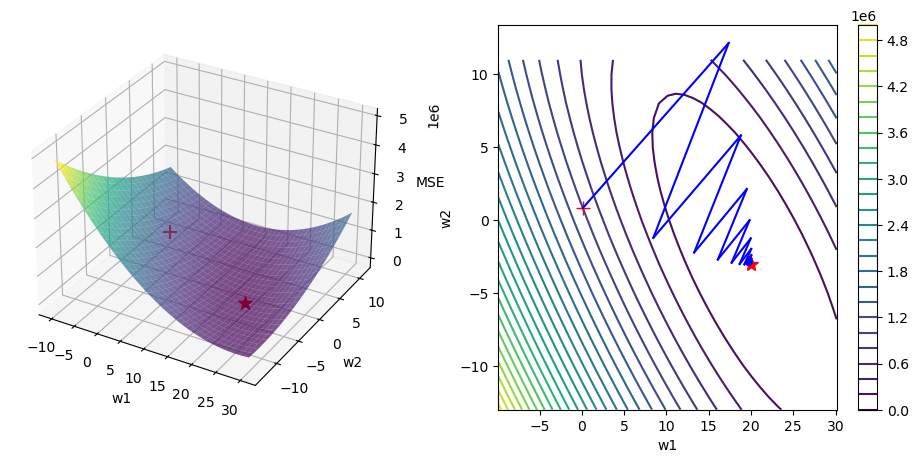

In [6]:
learning_rates_to_try = [0.0001, 0.00015, 0.0002]
K_values_to_try = [10, 20, 30]

best_mse = float('inf')
best_params = None
best_history = None

for lr in learning_rates_to_try:
    for K in K_values_to_try:
        print(f"Testing LR={lr}, K={K}...")
        start_time = time.time()
        ws_gd, history_gd = grad_desc_mse(K, ws0.copy(), lr, mse1, grad_loss, verbose=False)
        elapsed = time.time() - start_time
        
        final_mse = history_gd[-1]
        print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
        
        if final_mse < best_mse:
            best_mse = final_mse
            best_params = {'lr': lr, 'K': K}
            best_history = history_gd

print(f"\nBest: LR={best_params['lr']}, K={best_params['K']}, MSE={best_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_gd, history_gd = grad_desc_mse(
    best_params['K'], 
    ws0.copy(), 
    best_params['lr'], 
    mse1, 
    grad_loss, 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

## Stochastic Gradient Descent

First on the agenda is the faster, random gradient descent, aka 'Stochastic' Gradient Descent.

This works by computing smaller subsets (batches) of the complete dataset of samples to take more frequent/smaller steps per epoch instead of one singular calculated step.

One upside to using batches is computational speed and memory efficiency since the computer can perform many smaller steps instead of one giant leap every epoch.

Here we see that a smaller batch size lowers the computational time but doesn't necessarily impact the results.

In [7]:
def stochastic_grad_desc_mse(K, ws, learning_eps, loss, grad_loss, N, verbose=False):
    """Stochastic Gradient Descent"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Testing LR=0.0001, K=10, Batch size=10000...
  Final MSE: 7120.422377, Time: 0.1351s
Testing LR=0.0001, K=10, Batch size=5000...
  Final MSE: 185232.564531, Time: 0.1285s
Testing LR=0.0001, K=10, Batch size=2500...
  Final MSE: 712515.992305, Time: 0.1368s
Testing LR=0.0001, K=20, Batch size=10000...
  Final MSE: 324.856182, Time: 0.2598s
Testing LR=0.0001, K=20, Batch size=5000...
  Final MSE: 42898.352280, Time: 0.2466s
Testing LR=0.0001, K=20, Batch size=2500...
  Final MSE: 470260.533656, Time: 0.2861s
Testing LR=0.0001, K=50, Batch size=10000...
  Final MSE: 102.565391, Time: 0.6567s
Testing LR=0.0001, K=50, Batch size=5000...
  Final MSE: 660.923109, Time: 0.6627s
Testing LR=0.0001, K=50, Batch size=2500...
  Final MSE: 184638.702036, Time: 0.6138s
Testing LR=0.00015, K=10, Batch size=10000...
  Final MSE: 2050.859695, Time: 0.1315s
Testing LR=0.00015, K=10, Batch size=5000...
  Final MSE: 60984.711520, Time: 0.1261s
Testing LR=0.00015, K=10, Batch size=2500...
  Final MSE: 50374

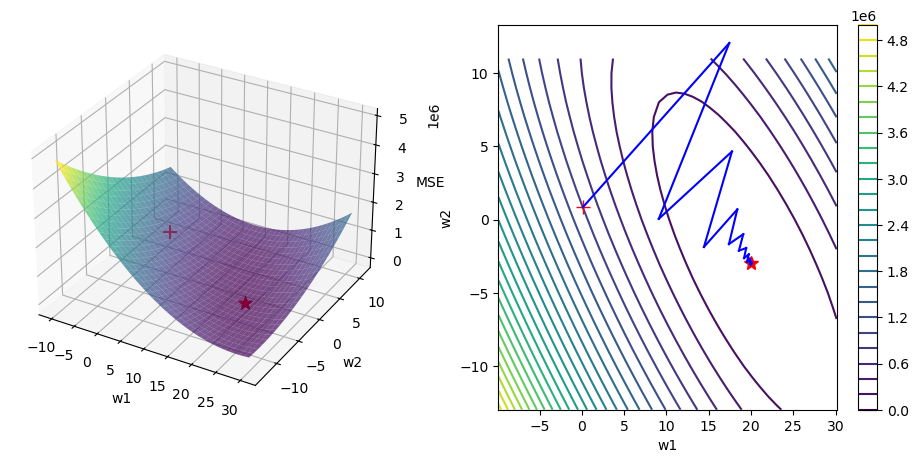

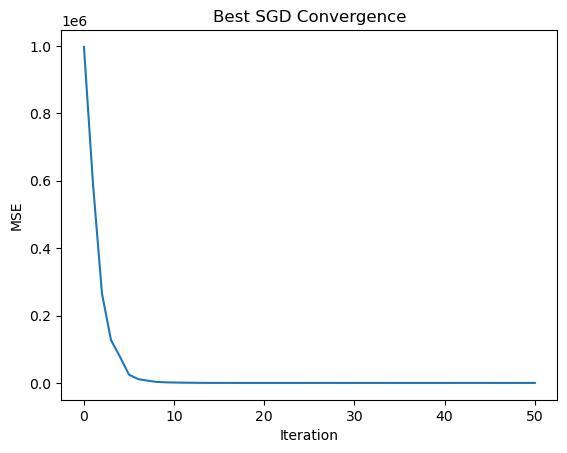

In [ ]:
learning_rates = [0.0001, 0.00015, 0.0002]
K_values = [10, 20, 50]
batch_sizes = [N*N, N*N//2, N*N//4]

best_sgd_mse = float('inf')
best_sgd_params = None
best_sgd_history = None

for lr in learning_rates:
    for K in K_values:
        for batch_size in batch_sizes:
            print(f"Testing LR={lr}, K={K}, Batch size={batch_size}...")
            start_time = time.time()
            ws_sgd, history_sgd = stochastic_grad_desc_mse(
                K, ws0.copy(), lr, mse1, grad_loss2, batch_size, verbose=False
            )
            elapsed = time.time() - start_time
            
            final_mse = history_sgd[-1]
            print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
            
            if final_mse < best_sgd_mse:
                best_sgd_mse = final_mse
                best_sgd_params = {'lr': lr, 'K': K, 'batch_size': batch_size}
                best_sgd_history = history_sgd

print(f"\nBest SGD: LR={best_sgd_params['lr']}, K={best_sgd_params['K']}, Batch size={best_sgd_params['batch_size'], }"
      f"MSE={best_sgd_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_sgd, history_sgd = stochastic_grad_desc_mse(
    best_sgd_params['K'], 
    ws0.copy(), 
    best_sgd_params['lr'], 
    mse1, 
    grad_loss2, 
    best_sgd_params['batch_size'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_sgd)), history_sgd)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best SGD Convergence')
plt.show()

## SGD with adaptive learning rate

Next up is the same thing but here we update the learning rate $\epsilon$ every iteration by

$$\epsilon_{k+1} = \epsilon_{k}\cdot(1-\alpha), \space \alpha \in [0, 1)$$

Here a larger $\alpha$ (closer to 1) means a more aggressive shrinking of the learning rate and in turn a slower convergence, while a smaller $\alpha$ might cause us to step over the local/global minima and cause us to end up in a local instead of a global minima. I found that an alpha around 0.01 works well for a lr = 0.0001.

In [9]:
def stochastic_adaptive_grad_desc_mse(K, ws, learning_eps, loss, grad_loss, N, alpha, verbose=False):
    """SGD with adaptive learning rate"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        learning_eps = (1 - alpha) * learning_eps
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Testing LR=0.0001, K=10, alpha=0.01...
  Final MSE: 7560.782694, Time: 0.1239s
Testing LR=0.0001, K=10, alpha=0.03...
  Final MSE: 9405.595140, Time: 0.1475s
Testing LR=0.0001, K=10, alpha=0.05...
  Final MSE: 15526.607634, Time: 0.1193s
Testing LR=0.0001, K=10, alpha=0.1...
  Final MSE: 22327.707065, Time: 0.1136s
Testing LR=0.0001, K=20, alpha=0.01...
  Final MSE: 486.214226, Time: 0.2010s
Testing LR=0.0001, K=20, alpha=0.03...
  Final MSE: 1313.935769, Time: 0.1850s
Testing LR=0.0001, K=20, alpha=0.05...
  Final MSE: 2408.561992, Time: 0.1994s
Testing LR=0.0001, K=20, alpha=0.1...
  Final MSE: 11687.668821, Time: 0.2234s
Testing LR=0.0001, K=50, alpha=0.01...
  Final MSE: 100.969154, Time: 0.4815s
Testing LR=0.0001, K=50, alpha=0.03...
  Final MSE: 124.400801, Time: 0.4601s
Testing LR=0.0001, K=50, alpha=0.05...
  Final MSE: 454.628748, Time: 0.4953s
Testing LR=0.0001, K=50, alpha=0.1...
  Final MSE: 7117.095850, Time: 0.4810s
Testing LR=0.00015, K=10, alpha=0.01...
  Final MSE: 237

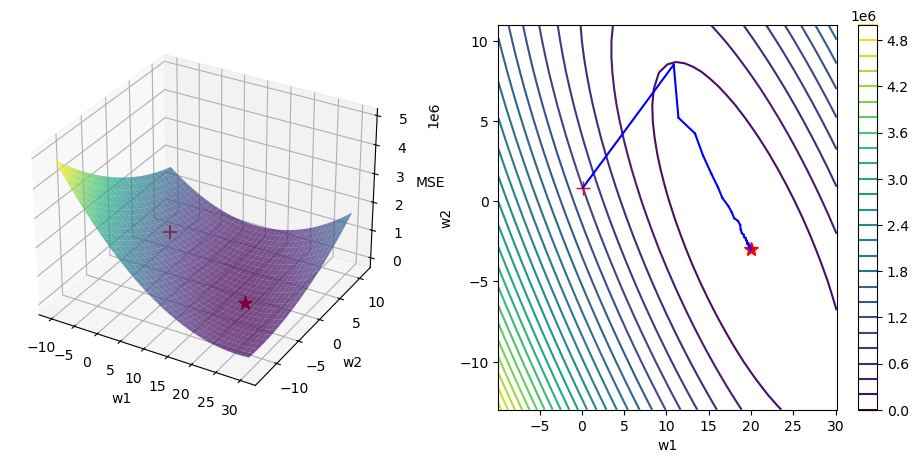

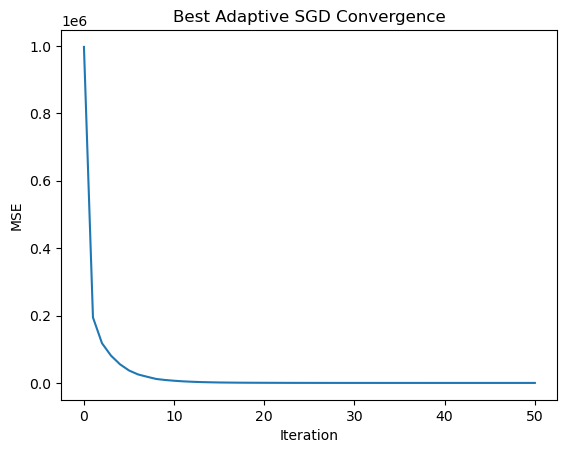

In [10]:
learning_rates = [0.0001, 0.00015, 0.0002]
K_values = [10, 20, 50]
alpha_values = [0.01, 0.03, 0.05, 0.1]

best_adaptive_mse = float('inf')
best_adaptive_params = None
best_adaptive_history = None

for lr in learning_rates:
    for K in K_values:
        for alpha in alpha_values:
            print(f"Testing LR={lr}, K={K}, alpha={alpha}...")
            start_time = time.time()
            ws_adaptive, history_adaptive = stochastic_adaptive_grad_desc_mse(
                K, ws0.copy(), lr, mse1, grad_loss2, N*N, alpha, verbose=False
            )
            elapsed = time.time() - start_time
            
            final_mse = history_adaptive[-1]
            print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
            
            if final_mse < best_adaptive_mse:
                best_adaptive_mse = final_mse
                best_adaptive_params = {'lr': lr, 'K': K, 'alpha': alpha}
                best_adaptive_history = history_adaptive

print(f"\nBest Adaptive SGD: LR={best_adaptive_params['lr']}, "
      f"K={best_adaptive_params['K']}, alpha={best_adaptive_params['alpha']}, "
      f"MSE={best_adaptive_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_adaptive, history_adaptive = stochastic_adaptive_grad_desc_mse(
    best_adaptive_params['K'], 
    ws0.copy(), 
    best_adaptive_params['lr'], 
    mse1, 
    grad_loss2, 
    N*N, 
    best_adaptive_params['alpha'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_adaptive)), history_adaptive)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best Adaptive SGD Convergence')
plt.show()

## SGD with momentum

Now we introduce 'momentum'.

This is trying to stop the optimization from 'zig-zagging' too much and keep the learning going 'downhill'.

As in regular mechanics, **momentum** is defined as **mass** times **velocity**, and so it shall remain in our case.

Here we use our gradient as our velocity and the new hyperparameter $m$ is thus the mass of the imaginary person walking along the gradient descent.

$$\epsilon_{k+1} = \epsilon_{k}\cdot\nabla J(\theta)\cdot m$$

A larger mass leads to less correction after each step and a good rule of thumb is to leave the initial learning rate small to avoid accruing too much momentum and missing completely. As seen in the gridsearch results, a mass too high usually spirals out of controll.

In [11]:
def stochastic_momentum_grad_desc_mse(K, ws, learning_eps, loss, grad_loss, N, mass, verbose=False):
    """SGD with momentum"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    v = 0
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        v = (v + grad_ws) / 2
        old_ws = ws.copy()
        ws = old_ws - mass * v - learning_eps * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Testing LR=5e-06, K=10, mass=0.0001...
  Final MSE: 4449.712599, Time: 0.1241s
Testing LR=5e-06, K=10, mass=0.0005...
  Final MSE: 14684393.505848, Time: 0.0957s
Testing LR=5e-06, K=10, mass=0.001...
  Final MSE: 24784486619893297152.000000, Time: 0.0987s
Testing LR=5e-06, K=10, mass=0.005...
  Final MSE: 65902764733559688449422127215411200.000000, Time: 0.0982s
Testing LR=5e-06, K=20, mass=0.0001...
  Final MSE: 118.644490, Time: 0.2064s
Testing LR=5e-06, K=20, mass=0.0005...
  Final MSE: 2202097.160555, Time: 0.1996s
Testing LR=5e-06, K=20, mass=0.001...
  Final MSE: 21009243386237141383353192153088.000000, Time: 0.1947s
Testing LR=5e-06, K=20, mass=0.005...
  Final MSE: 2216593494788750592389234773581406703714415279386105504115720192.000000, Time: 0.1898s
Testing LR=5e-06, K=30, mass=0.0001...
  Final MSE: 101.062790, Time: 0.2840s
Testing LR=5e-06, K=30, mass=0.0005...
  Final MSE: 262976913357.660095, Time: 0.2706s
Testing LR=5e-06, K=30, mass=0.001...
  Final MSE: 288037284515053

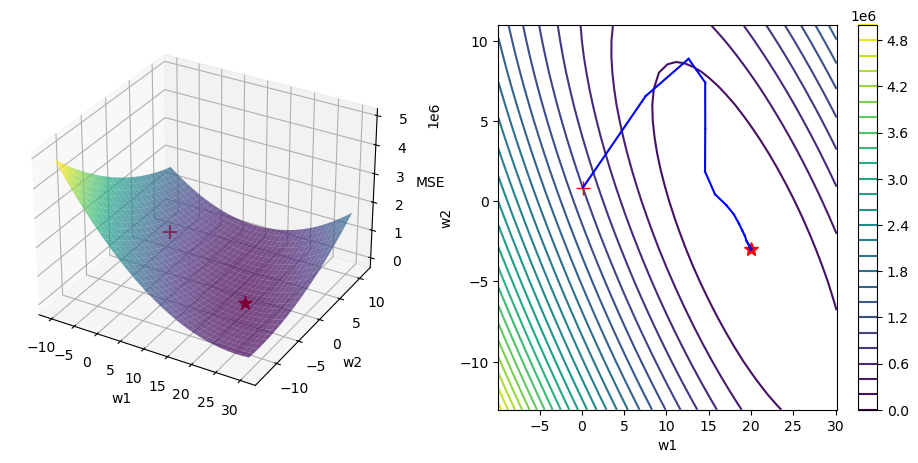

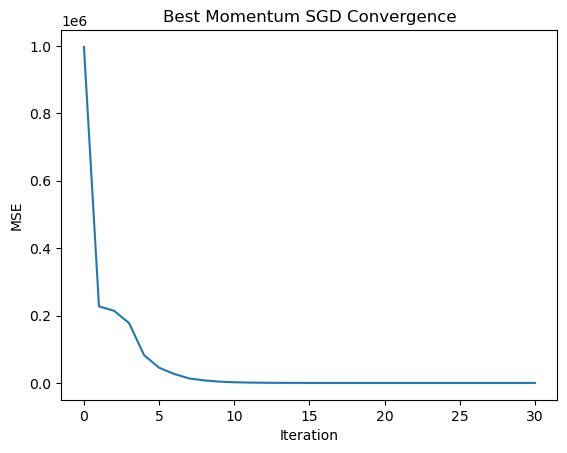

In [ ]:
learning_rates = [0.000005, 0.00001, 0.00002, 0.00005]
K_values = [10, 20, 30, 50]
mass_values = [0.0001, 0.0005, 0.001, 0.005]

best_momentum_mse = float('inf')
best_momentum_params = None
best_momentum_history = None

for lr in learning_rates:
    for K in K_values:
        for mass in mass_values:
            print(f"Testing LR={lr}, K={K}, mass={mass}...")
            start_time = time.time()
            ws_momentum, history_momentum = stochastic_momentum_grad_desc_mse(
                K, ws0.copy(), lr, mse1, grad_loss2, N*N, mass, verbose=False
            )
            elapsed = time.time() - start_time
            
            final_mse = history_momentum[-1]
            print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
            
            if final_mse < best_momentum_mse:
                best_momentum_mse = final_mse
                best_momentum_params = {'lr': lr, 'K': K, 'mass': mass}
                best_momentum_history = history_momentum

print(f"\nBest Momentum SGD: LR={best_momentum_params['lr']}, "
      f"K={best_momentum_params['K']}, mass={best_momentum_params['mass']}, "
      f"MSE={best_momentum_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_momentum, history_momentum = stochastic_momentum_grad_desc_mse(
    best_momentum_params['K'], 
    ws0.copy(), 
    best_momentum_params['lr'], 
    mse1, 
    grad_loss2, 
    N*N, 
    best_momentum_params['mass'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_momentum)), history_momentum)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best Momentum SGD Convergence')
plt.show()

## SGD with accumulated squared gradient: AdaGrad

Now on to something new, Adaptive Gradient, AdaGrad.

This method adapts the learning rate for each parameter depending on how steep the gradient is and the 'history' of it's gradients, implementing a sum of squares of past gradients for that parameter.

Assume parameter $\theta_i$ at iteration $t$, then the update looks like this:

$$\theta_{t+1,i} = \theta_{t,i} - \frac{\epsilon}{\sqrt{\sum_{\tau} g_{\tau,i}^2 + \delta}}\cdot g_{t,i},$$

where $g_{t,i}$ is the gradient of parameter $\theta_i$ at iteration $t$ and $\delta$ is a small smoothing constant.

Here the stagnation of the learning rate is quite fast so we need to increase the size of the learning rate to unusually high numbers.

In [13]:
def ada_grad_mse(K, ws, learning_eps, loss, grad_loss, N, verbose=False):
    """AdaGrad optimizer"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    r = np.zeros(len(ws))
    delta = 1e-10 * np.ones(len(ws))
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        r = r + grad_ws * grad_ws
        ws = old_ws - learning_eps / (delta + np.sqrt(r)) * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Testing LR=10, K=10...
  Final MSE: 5716.491661, Time: 0.1595s
Testing LR=10, K=20...
  Final MSE: 303.873398, Time: 0.2521s
Testing LR=10, K=30...
  Final MSE: 130.087228, Time: 0.3911s
Testing LR=10, K=50...
  Final MSE: 101.064484, Time: 0.7230s
Testing LR=25, K=10...
  Final MSE: 7097.415641, Time: 0.1620s
Testing LR=25, K=20...
  Final MSE: 193.602138, Time: 0.2930s
Testing LR=25, K=30...
  Final MSE: 103.022039, Time: 0.3948s
Testing LR=25, K=50...
  Final MSE: 104.235722, Time: 0.6900s
Testing LR=50, K=10...
  Final MSE: 10947.126445, Time: 0.1515s
Testing LR=50, K=20...
  Final MSE: 1173.827674, Time: 0.2673s
Testing LR=50, K=30...
  Final MSE: 106.270953, Time: 0.4099s
Testing LR=50, K=50...
  Final MSE: 105.057099, Time: 0.6275s

Best AdaGrad: LR=10, K=50, MSE=101.064484
Time: 0.462859 seconds


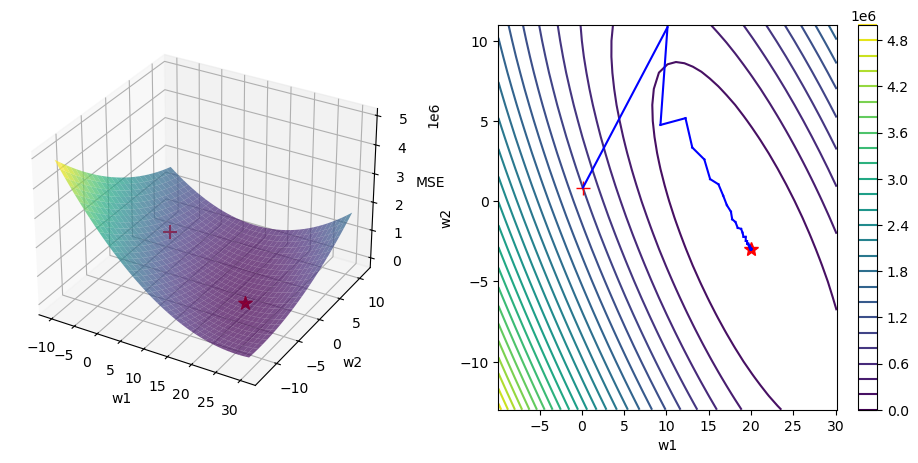

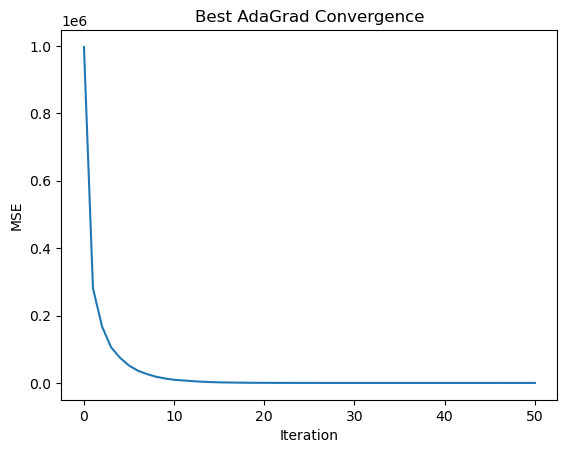

In [25]:
learning_rates = [10, 25, 50]
K_values = [10, 20, 30, 50]

best_ada_mse = float('inf')
best_ada_params = None
best_ada_history = None

for lr in learning_rates:
    for K in K_values:
        print(f"Testing LR={lr}, K={K}...")
        start_time = time.time()
        ws_ada, history_ada = ada_grad_mse(
            K, ws0.copy(), lr, mse1, grad_loss2, N*N, verbose=False
        )
        elapsed = time.time() - start_time
        
        final_mse = history_ada[-1]
        print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
        
        if final_mse < best_ada_mse:
            best_ada_mse = final_mse
            best_ada_params = {'lr': lr, 'K': K}
            best_ada_history = history_ada

print(f"\nBest AdaGrad: LR={best_ada_params['lr']}, "
      f"K={best_ada_params['K']}, MSE={best_ada_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_ada, history_ada = ada_grad_mse(
    best_ada_params['K'], 
    ws0.copy(), 
    best_ada_params['lr'], 
    mse1, 
    grad_loss2, 
    N*N, 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_ada)), history_ada)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best AdaGrad Convergence')
plt.show()

## SGD with accumulated squared gradient: RMSProp

This time we try Root Mean Square Propagation, RMSProp.

This method is designed to counter the fatal flaw of AdaGrad, stagnating learning rate for larger numbers of iterations. This is done by adding the hyperparameter $\rho \in [0, 1]$, being a weight to decide how much the next learning rate should depend on the squared sum of gradients and just the last step.

So instead of simply adding the squares,
$$r_{k+1} = r_k + g^2,$$
we now add the weight term $\rho$,
$$r_{k+1} = r_k\cdot\rho + (1 - \rho)\cdot g^2.$$

Here we see that this problem favours relying on the past as the gridsearch decided that the best $\rho$ is 0.95 with the other hyperparameters.

In [15]:
def rms_prob_mse(K, ws, learning_eps, loss, grad_loss, N, rho, verbose=False):
    """RMSProp optimizer"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    r = np.zeros(len(ws))
    delta = 1e-10 * np.ones(len(ws))
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        r = rho * r + (1 - rho) * grad_ws * grad_ws
        ws = old_ws - learning_eps / (np.sqrt(delta + r)) * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Testing LR=0.5, K=10, rho=0.7...
  Final MSE: 330082.237070, Time: 0.1042s
Testing LR=0.5, K=10, rho=0.8...
  Final MSE: 299757.582438, Time: 0.0930s
Testing LR=0.5, K=10, rho=0.9...
  Final MSE: 245192.007062, Time: 0.0968s
Testing LR=0.5, K=10, rho=0.95...
  Final MSE: 172865.398446, Time: 0.1015s
Testing LR=0.5, K=20, rho=0.7...
  Final MSE: 167720.076782, Time: 0.1907s
Testing LR=0.5, K=20, rho=0.8...
  Final MSE: 155471.944606, Time: 0.1836s
Testing LR=0.5, K=20, rho=0.9...
  Final MSE: 136812.327714, Time: 0.1835s
Testing LR=0.5, K=20, rho=0.95...
  Final MSE: 96364.698959, Time: 0.1812s
Testing LR=0.5, K=30, rho=0.7...
  Final MSE: 59958.195218, Time: 0.2742s
Testing LR=0.5, K=30, rho=0.8...
  Final MSE: 64766.734170, Time: 0.2744s
Testing LR=0.5, K=30, rho=0.9...
  Final MSE: 63522.575780, Time: 0.2876s
Testing LR=0.5, K=30, rho=0.95...
  Final MSE: 49174.969667, Time: 0.2967s
Testing LR=0.5, K=50, rho=0.7...
  Final MSE: 707.587356, Time: 0.4593s
Testing LR=0.5, K=50, rho=0.8.

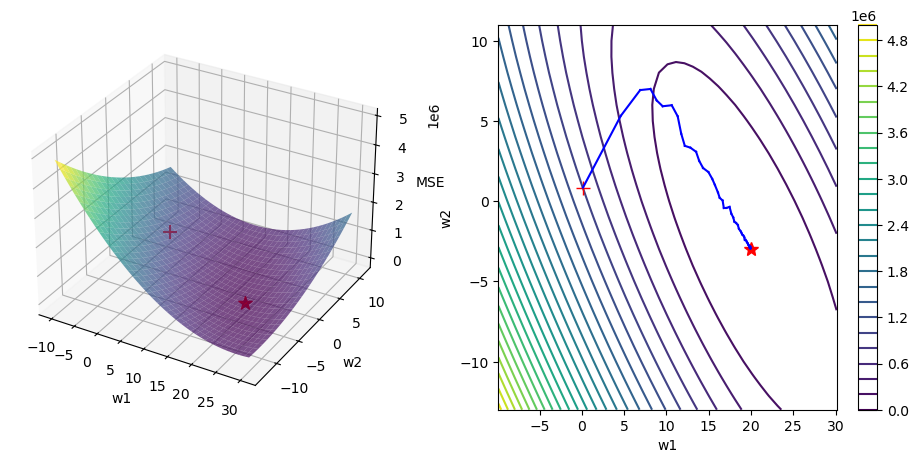

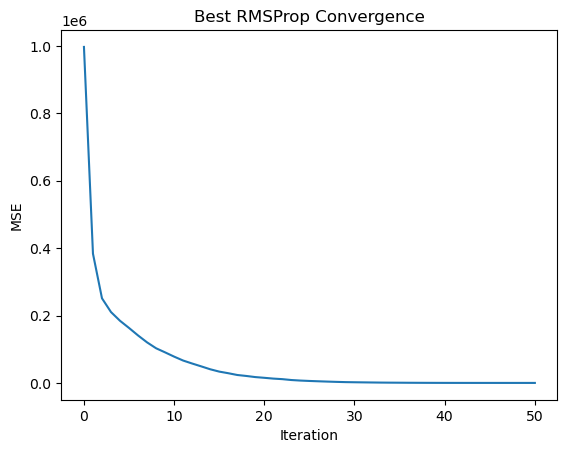

In [16]:
learning_rates = [0.5, 1, 2, 5]
K_values = [10, 20, 30, 50]
rho_values = [0.7, 0.8, 0.9, 0.95]

best_rms_mse = float('inf')
best_rms_params = None
best_rms_history = None

for lr in learning_rates:
    for K in K_values:
        for rho in rho_values:
            print(f"Testing LR={lr}, K={K}, rho={rho}...")
            start_time = time.time()
            ws_rms, history_rms = rms_prob_mse(
                K, ws0.copy(), lr, mse1, grad_loss2, N*N, rho, verbose=False
            )
            elapsed = time.time() - start_time
            
            final_mse = history_rms[-1]
            print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
            
            if final_mse < best_rms_mse:
                best_rms_mse = final_mse
                best_rms_params = {'lr': lr, 'K': K, 'rho': rho}
                best_rms_history = history_rms

print(f"\nBest RMSProp: LR={best_rms_params['lr']}, "
      f"K={best_rms_params['K']}, rho={best_rms_params['rho']}, "
      f"MSE={best_rms_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_rms, history_rms = rms_prob_mse(
    best_rms_params['K'], 
    ws0.copy(), 
    best_rms_params['lr'], 
    mse1, 
    grad_loss2, 
    N*N, 
    best_rms_params['rho'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_rms)), history_rms)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best RMSProp Convergence')
plt.show()

## SGD with accumulated squared gradient: ADAM

The last accumulated squared gradient version to try here is ADAM, Adaptive Moment Estimation.

This is the method to use when you want the statbility of momentum and the magnitude from RMSProp. ADAM combines these two methods with one slight twist, the mass hyperparameter $m$ from momentum is now set to 1 and we now controll the velocity with $\rho_1 \in [0, 1]$ to compute how much of the past momentum we want to consider in our next step. Similarily, the RMSProp hyperparameter is now called $\rho_2 \in [0, 1]$.

Since velocity and momentum are both initialized as 0, they are both biased towards 0, so we must correct this by

$$\hat s = \frac{s}{1 - \rho_1}, \hat r = \frac{r}{1 - \rho_2}.$$

For this problem the grid-search got quite large, $(4^4)$, so there are a lot of variance in how the parameters affect the training, but looking for some type of pattern it seems that higher K values (epochs) lead to smaller losses (as is expected as long as we have convergence). Aside from the obvious I can see that a higher $\rho_2$ value gives better results and a lower $\rho_1$ value pairs better with higher $\rho_2$ values. This means that for this problem, lower velocity retention and a higher reliance on the past is better.

In [17]:
def adam_mse(K, ws, learning_eps, loss, grad_loss, N, rho1, rho2, verbose=False):
    """ADAM optimizer"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    s = np.zeros(len(ws))
    r = np.zeros(len(ws))
    t = 0
    delta = 1e-10 * np.ones(len(ws))
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        t += 1
        s = rho1 * s + (1 - rho1) * grad_ws
        r = rho2 * r + (1 - rho2) * grad_ws * grad_ws
        s_hat = s / (1 - rho1**t)
        r_hat = r / (1 - rho2**t)
        ws = old_ws - (learning_eps * s_hat) / (delta + np.sqrt(r_hat))
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Testing LR=1, K=10, rho1=0.3, rho2=0.9...
  Final MSE: 204009.383671, Time: 0.1102s
Testing LR=1, K=10, rho1=0.3, rho2=0.95...
  Final MSE: 217229.468084, Time: 0.0938s
Testing LR=1, K=10, rho1=0.3, rho2=0.99...
  Final MSE: 210395.901274, Time: 0.1003s
Testing LR=1, K=10, rho1=0.3, rho2=0.999...
  Final MSE: 215906.852142, Time: 0.0965s
Testing LR=1, K=10, rho1=0.5, rho2=0.9...
  Final MSE: 192980.500985, Time: 0.0930s
Testing LR=1, K=10, rho1=0.5, rho2=0.95...
  Final MSE: 210484.970931, Time: 0.0967s
Testing LR=1, K=10, rho1=0.5, rho2=0.99...
  Final MSE: 209233.592176, Time: 0.0961s
Testing LR=1, K=10, rho1=0.5, rho2=0.999...
  Final MSE: 214924.872239, Time: 0.0942s
Testing LR=1, K=10, rho1=0.7, rho2=0.9...
  Final MSE: 203781.685483, Time: 0.0985s
Testing LR=1, K=10, rho1=0.7, rho2=0.95...
  Final MSE: 205810.156574, Time: 0.0946s
Testing LR=1, K=10, rho1=0.7, rho2=0.99...
  Final MSE: 204282.159608, Time: 0.1001s
Testing LR=1, K=10, rho1=0.7, rho2=0.999...
  Final MSE: 199277.11

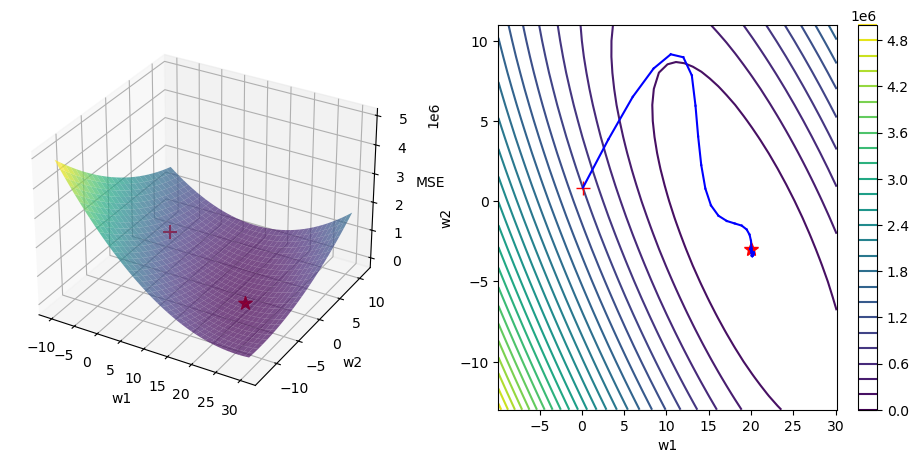

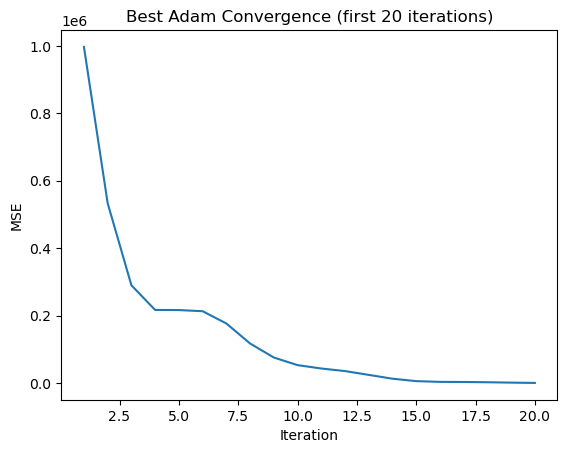

In [ ]:
learning_rates = [1, 3, 5, 10]
K_values = [10, 20, 30, 50]
rho1_values = [0.3, 0.5, 0.7, 0.9]
rho2_values = [0.9, 0.95, 0.99, 0.999]

best_adam_mse = float('inf')
best_adam_params = None
best_adam_history = None

for lr in learning_rates:
    for K in K_values:
        for rho1 in rho1_values:
            for rho2 in rho2_values:
                print(f"Testing LR={lr}, K={K}, rho1={rho1}, rho2={rho2}...")
                start_time = time.time()
                ws_adam, history_adam = adam_mse(
                    K, ws0.copy(), lr, mse1, grad_loss2, N*N, rho1, rho2, verbose=False
                )
                elapsed = time.time() - start_time
                
                final_mse = history_adam[-1]
                print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
                
                if final_mse < best_adam_mse:
                    best_adam_mse = final_mse
                    best_adam_params = {'lr': lr, 'K': K, 'rho1': rho1, 'rho2': rho2}
                    best_adam_history = history_adam

print(f"\nBest Adam: LR={best_adam_params['lr']}, "
      f"K={best_adam_params['K']}, rho1={best_adam_params['rho1']}, "
      f"rho2={best_adam_params['rho2']}, MSE={best_adam_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_adam, history_adam = adam_mse(
    best_adam_params['K'], 
    ws0.copy(), 
    best_adam_params['lr'], 
    mse1, 
    grad_loss2, 
    N*N, 
    best_adam_params['rho1'], 
    best_adam_params['rho2'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(1, min(len(history_adam), 21)), history_adam[:20])
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best Adam Convergence (first 20 iterations)')
plt.show()

## SGD with Newton’s method

Next up, a more analytical solution to our optimization problem, namely the Newton method.

These solutions rely on the computed matrix $H$, the hessian of the loss function, to be invertible, which it should be, bit can be very computationally expensive to compute.

This method is very similar to the regular Newton method, except here we only use a subset of the samples to compute the hessian $H$.

In our simple case, this is the clear winner in terms of speed since the hessian is only $N\cdot N$, but this can quickly become the slowest method since the complexity increases by $O(N^2)$. Important to note is also that when using too small batches like 100, 64 and so on, the matrix H can become singular and crash the training.

In [19]:
def stochastic_newton_mse(K, ws, loss, grad_loss, grad2_loss, N, verbose=False):
    """Stochastic Newton's method"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        H = grad2_loss(ws, randices)
        ws = old_ws - inv(H) @ grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

def hessian_mse(ws, X):
    """Compute Hessian matrix for MSE"""
    N = len(X)
    M = len(ws)
    H = np.zeros((M, M))
    for r in range(M):
        for c in range(M):
            for i in range(N):
                H[r, c] += X[i, r] * X[i, c]
    return 2/N * H

Testing K=1, batch_size=10000...
  Final MSE: 101.146692, Time: 0.0240s
Testing K=1, batch_size=5000...
  Final MSE: 121.529355, Time: 0.0255s
Testing K=1, batch_size=2500...
  Final MSE: 129.072821, Time: 0.0173s
Testing K=2, batch_size=10000...
  Final MSE: 102.773945, Time: 0.0262s
Testing K=2, batch_size=5000...
  Final MSE: 104.858841, Time: 0.0251s
Testing K=2, batch_size=2500...
  Final MSE: 133.301926, Time: 0.0246s

Best Newton: K=1, batch_size=10000, MSE=101.146692
Time: 0.018100 seconds


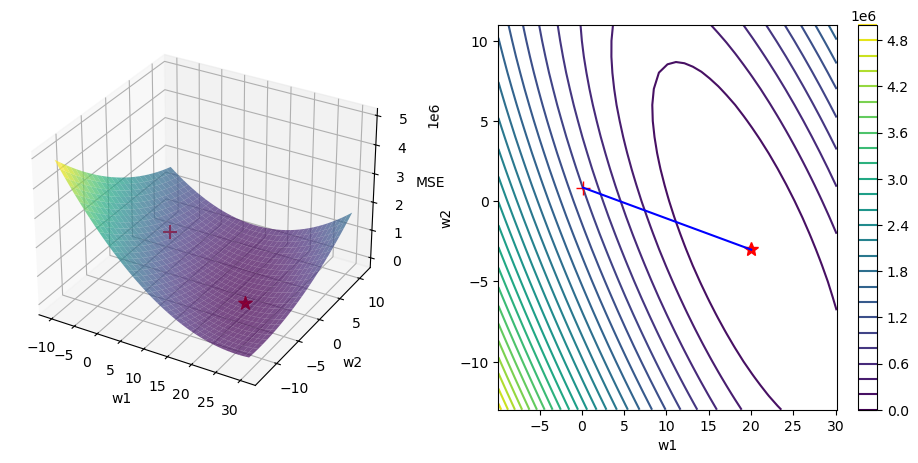

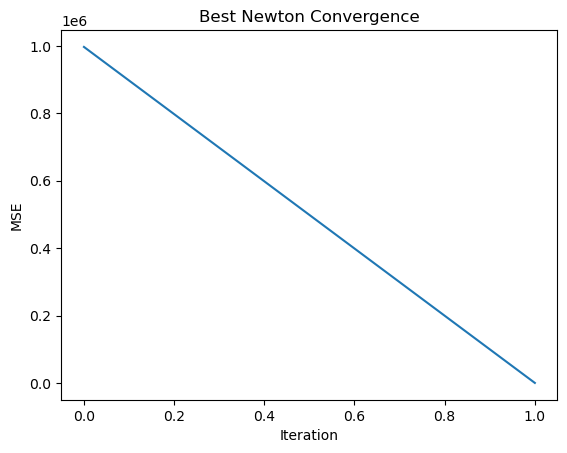

In [20]:
K_values = [1, 2]
batch_sizes = [N*N, N*N//2, N*N//4]

best_newton_mse = float('inf')
best_newton_params = None
best_newton_history = None

for K in K_values:
    for batch_size in batch_sizes:
        grad2_loss = lambda ws, randices: hessian_mse(ws, XX[randices])
        
        print(f"Testing K={K}, batch_size={batch_size}...")
        start_time = time.time()
        ws_newton, history_newton = stochastic_newton_mse(
            K, ws0.copy(), mse1, grad_loss2, grad2_loss, batch_size, verbose=False
        )
        elapsed = time.time() - start_time
        
        final_mse = history_newton[-1]
        print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
        
        if final_mse < best_newton_mse:
            best_newton_mse = final_mse
            best_newton_params = {'K': K, 'batch_size': batch_size}
            best_newton_history = history_newton

print(f"\nBest Newton: K={best_newton_params['K']}, "
      f"batch_size={best_newton_params['batch_size']}, MSE={best_newton_mse:.6f}")

# Run with best parameters
grad2_loss = lambda ws, randices: hessian_mse(ws, XX[randices])
ax = setup_plot()
start_time = time.time()
ws_newton, history_newton = stochastic_newton_mse(
    best_newton_params['K'], 
    ws0.copy(), 
    mse1, 
    grad_loss2, 
    grad2_loss, 
    best_newton_params['batch_size'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_newton)), history_newton)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best Newton Convergence')
plt.show()

## SGD with the conjugate gradient method

Now we consider a more interesting method, the conjugate gradient method.

In this method we try to find the minima of a projected line in the direction of the stochastic gradient, to iteratively optimize the parameters. This can be done by using other optimization methods to find the minima along each line.

### The naive method

Here we try to find the minima by looking at points along each line and computing the loss at each point to find the minima.

The conjugate gradient method is slow when using the naive method, since we explicitly compute the loss for extremely many points along the projected line in loss-space, but even here we can see that smaller batch sizes reduce computation time almost linearly. The best hyperparameters found in the grid search are as follows:
- Learning Rate: 0.0001
- K: 5
- Batch Size: N*N = 10'000

These hyperparametersare not the fastest, they are infact the slowest, a sort of trade-off between computation speed and precision.

In [34]:
def grad_eps(eps, ws, rho, m, X, Y):
    """Gradient with respect to epsilon for line search"""
    N = len(X)
    grad = 0
    for i in range(N):
        xi = X[i]
        yi = Y[i]
        tmp = yi - m(ws + eps * rho, xi)
        grad += tmp * (rho @ xi)
    return -2/N * grad

def grad2_eps(rho, X):
    """Second derivative with respect to epsilon for line search"""
    N = len(X)
    grad2 = 0
    for i in range(N):
        xi = X[i]
        tmp = rho @ xi
        grad2 += tmp**2
    return 2/N * grad2

def cg_mse(K, ws, lr, loss, stochastic_loss, grad_loss, N, verbose=False):
    """Conjugate Gradient method"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    rho_old = np.zeros(len(ws))
    grad_ws_old = np.zeros(len(ws))
    
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        
        if k == 0:
            rho = -grad_ws
        else:
            beta = ((grad_ws - grad_ws_old) @ grad_ws) / (grad_ws_old @ grad_ws_old)
            rho = -grad_ws + beta * rho_old
        
        # Naive line search
        epsilon_star = np.inf
        minimum_star = np.inf
        
        epsilons = np.arange(0, 1, lr)[1:]
        for epsilon in epsilons:
            minimum = stochastic_loss(ws + epsilon * rho, randices)
            if minimum < minimum_star:
                epsilon_star = epsilon
                minimum_star = minimum
        
        old_ws = ws.copy()
        ws = old_ws + epsilon_star * rho
        rho_old = rho
        grad_ws_old = grad_ws
        
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    
    return ws, history

Testing LR=1e-05, K=5, batch_size=10000...
  Final MSE: 100.744738, Time: 55.3536s
Testing LR=1e-05, K=5, batch_size=5000...
  Final MSE: 104.516337, Time: 30.0188s
Testing LR=1e-05, K=5, batch_size=2500...
  Final MSE: 366.744898, Time: 19.2353s
Testing LR=1e-05, K=10, batch_size=10000...
  Final MSE: 712.465299, Time: 105.0055s
Testing LR=1e-05, K=10, batch_size=5000...
  Final MSE: 130.892543, Time: 60.6432s
Testing LR=1e-05, K=10, batch_size=2500...
  Final MSE: 371.029393, Time: 38.8119s
Testing LR=5e-05, K=5, batch_size=10000...
  Final MSE: 557.420733, Time: 10.7714s
Testing LR=5e-05, K=5, batch_size=5000...
  Final MSE: 140.521260, Time: 6.1329s
Testing LR=5e-05, K=5, batch_size=2500...
  Final MSE: 507.350460, Time: 3.8624s
Testing LR=5e-05, K=10, batch_size=10000...
  Final MSE: 101.274105, Time: 21.0698s
Testing LR=5e-05, K=10, batch_size=5000...
  Final MSE: 4665.205750, Time: 12.1494s
Testing LR=5e-05, K=10, batch_size=2500...
  Final MSE: 56608230036430904.000000, Time: 7

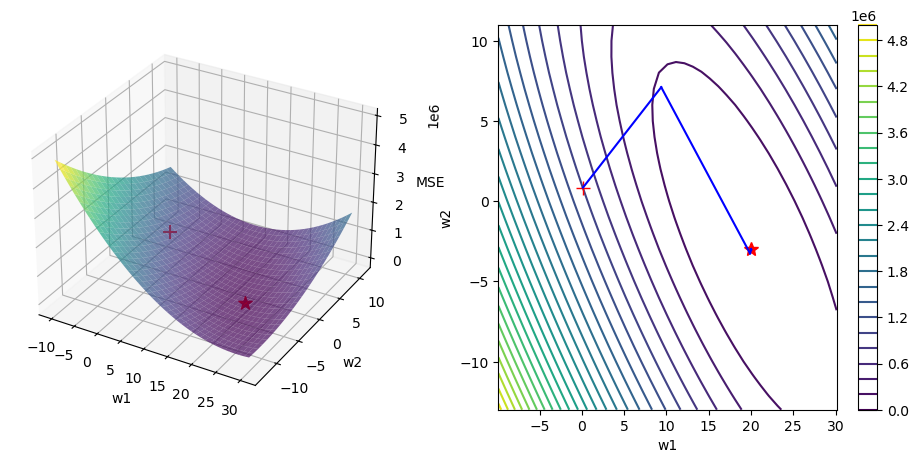

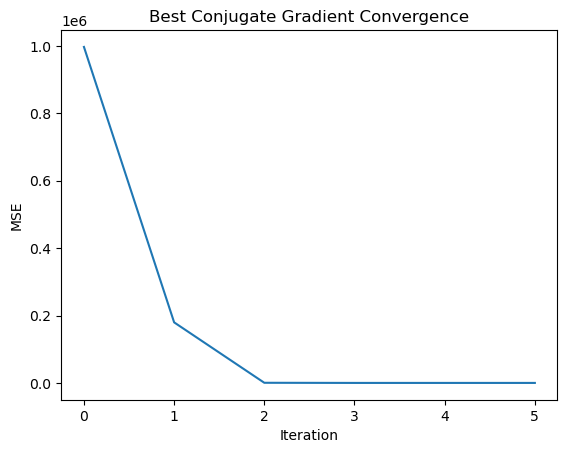

In [35]:
K_values = [5, 10]
learning_rates = [0.00001, 0.00005, 0.0001]
batch_sizes = [N*N, N*N//2, N*N//4]

best_cg_mse = float('inf')
best_cg_params = None
best_cg_history = None

for learning_rate in learning_rates:
    for K in K_values:
        for batch_size in batch_sizes:
            mse2 = lambda ws, randices: mse(ws, m1, XX[randices], Y[randices])
            stochastic_grad_eps_fn = lambda eps, ws, rho, randices: grad_eps(eps, ws, rho, m1, XX[randices], Y[randices])
            stochastic_grad2_eps_fn = lambda rho, randices: grad2_eps(rho, XX[randices])
            
            print(f"Testing LR={learning_rate}, K={K}, batch_size={batch_size}...")
            start_time = time.time()
            ws_cg, history_cg = cg_mse(
                K, ws0.copy(), learning_rate, mse1, mse2, grad_loss2, batch_size, verbose=False
            )
            elapsed = time.time() - start_time
            
            final_mse = history_cg[-1]
            print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
            
            if final_mse < best_cg_mse:
                best_cg_mse = final_mse
                best_cg_params = {'LR': learning_rate, 'K': K, 'batch_size': batch_size}
                best_cg_history = history_cg

print(f"\nBest CG: LR={best_cg_params['LR']}, K={best_cg_params['K']}, "
      f"batch_size={best_cg_params['batch_size']}, MSE={best_cg_mse:.6f}")

# Run with best parameters
mse2 = lambda ws, randices: mse(ws, m1, XX[randices], Y[randices])
stochastic_grad_eps_fn = lambda eps, ws, rho, randices: grad_eps(eps, ws, rho, m1, XX[randices], Y[randices])
stochastic_grad2_eps_fn = lambda rho, randices: grad2_eps(rho, XX[randices])

ax = setup_plot()
start_time = time.time()
ws_cg, history_cg = cg_mse(
    best_cg_params['K'],
    ws0.copy(),
    best_cg_params['LR'],
    mse1,
    mse2,
    grad_loss2,
    best_cg_params['batch_size'],
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_cg)), history_cg)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best Conjugate Gradient Convergence')
plt.show()

## The implemented Newton method

And here we implement the Newton method to analytically find the minima along each line.

Compared to the naive method of trying to iteratively find smaller values for the loss by explicitly computing the loss at every point along a line, we here use newtons method to significantly reduce the time spent computing losses for points. This method is orders of magnitude faster than the naive method and if you look at the produced plots, it seems that both methods took a similar path when training, but with vastly different speeds.

In [36]:
def cg_mse_newton(K, ws, loss, grad_loss, stochastic_grad_eps, stochastic_grad2_eps, N, verbose=False):
    """Conjugate Gradient with Newton's method for line search"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    rho_old = np.zeros(len(ws))
    grad_ws_old = np.zeros(len(ws))
    
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        
        if k == 0:
            rho = -grad_ws
        else:
            beta = ((grad_ws - grad_ws_old) @ grad_ws) / (grad_ws_old @ grad_ws_old)
            rho = -grad_ws + beta * rho_old
        
        # Newton line search
        epsilon_star = 0.5
        grad_val = stochastic_grad_eps(epsilon_star, ws, rho, randices)
        h = stochastic_grad2_eps(rho, randices)
        epsilon_star = epsilon_star - grad_val / h
        
        old_ws = ws.copy()
        ws = old_ws + epsilon_star * rho
        rho_old = rho
        grad_ws_old = grad_ws
        
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    
    return ws, history

Testing K=5, batch_size=10000...
  Final MSE: 101.078180, Time: 0.1025s
Testing K=5, batch_size=5000...
  Final MSE: 102.454443, Time: 0.0751s
Testing K=5, batch_size=2500...
  Final MSE: 103.758228, Time: 0.0804s
Testing K=10, batch_size=10000...
  Final MSE: 101.806089, Time: 0.1907s
Testing K=10, batch_size=5000...
  Final MSE: 110.545318, Time: 0.1369s
Testing K=10, batch_size=2500...
  Final MSE: 848.495353, Time: 0.1323s

Best CG-Newton: K=5, batch_size=10000, MSE=101.078180
Time: 0.068838 seconds


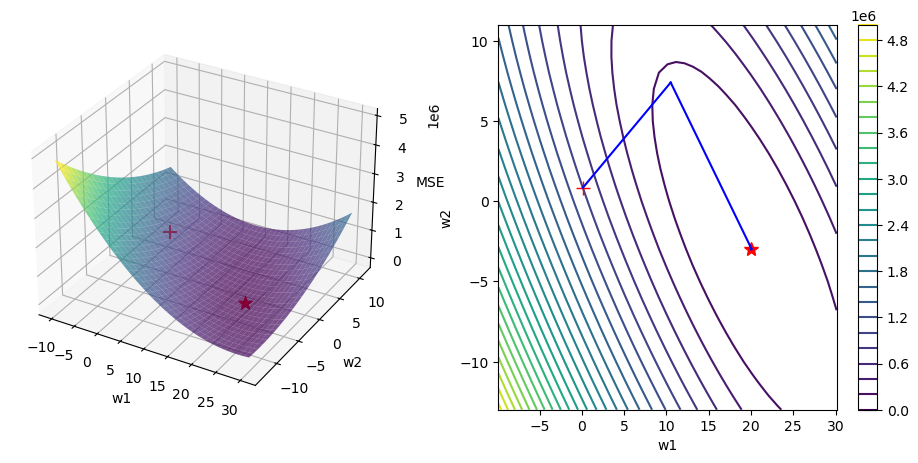

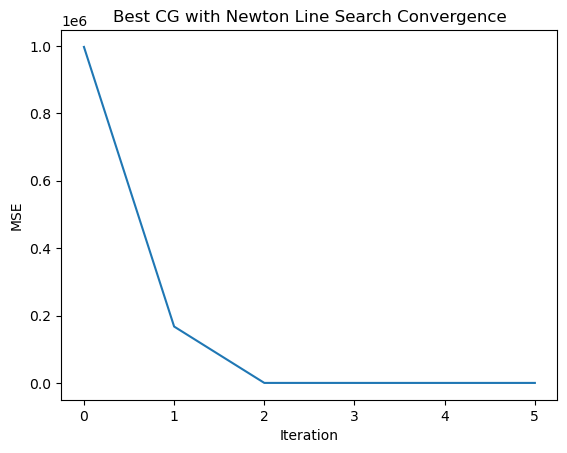

In [37]:
K_values = [5, 10]
batch_sizes = [N*N, N*N//2, N*N//4]

best_cg_newton_mse = float('inf')
best_cg_newton_params = None
best_cg_newton_history = None

for K in K_values:
    for batch_size in batch_sizes:
        print(f"Testing K={K}, batch_size={batch_size}...")
        start_time = time.time()
        ws_cg_newton, history_cg_newton = cg_mse_newton(
            K, ws0.copy(), mse1, grad_loss2, 
            stochastic_grad_eps_fn, stochastic_grad2_eps_fn, 
            batch_size, verbose=False
        )
        elapsed = time.time() - start_time
        
        final_mse = history_cg_newton[-1]
        print(f"  Final MSE: {final_mse:.6f}, Time: {elapsed:.4f}s")
        
        if final_mse < best_cg_newton_mse:
            best_cg_newton_mse = final_mse
            best_cg_newton_params = {'K': K, 'batch_size': batch_size}
            best_cg_newton_history = history_cg_newton

print(f"\nBest CG-Newton: K={best_cg_newton_params['K']}, "
      f"batch_size={best_cg_newton_params['batch_size']}, MSE={best_cg_newton_mse:.6f}")

# Run with best parameters
ax = setup_plot()
start_time = time.time()
ws_cg_newton, history_cg_newton = cg_mse_newton(
    best_cg_newton_params['K'], 
    ws0.copy(), 
    mse1, 
    grad_loss2, 
    stochastic_grad_eps_fn, 
    stochastic_grad2_eps_fn, 
    best_cg_newton_params['batch_size'], 
    verbose=True
)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_cg_newton)), history_cg_newton)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Best CG with Newton Line Search Convergence')
plt.show()